<!-- ---
title: "Análise hospitalização x não hospitalização"
format:
  html:
    theme: darkly
    toc: false
    code-fold: true  
    echo: false
    embed-resources: true
    page-layout: full
    include-in-header: 
      - text: |
          <script src="https://cdn.plot.ly/plotly-latest.min.js"></script>
jupyter: python3
--- -->


In [31]:
# import plotly.io as pio
# pio.renderers.default = "iframe_connected"   # ou "iframe"


## Tratamento

In [32]:
import pandas as pd
import plotly.express as px
import numpy as np
from src import utils
from datetime import datetime
from sklearn import preprocessing
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

In [33]:
result = pd.read_parquet("fontes/base_2019.parquet")

In [34]:
base = (result
      .assign(HOSPITALIZ = lambda _df: np.where(_df['HOSPITALIZ'] == 0, 'Não hospitalizou', 'Sim, hospitalizou'))
)

In [35]:
sexo = 'Sexo'
gestante = 'Gestante'
raca = 'Raça'
escolaridade = 'Escolaridade'
age_group = 'Faixa etária'

df = (
    base
    .assign(**{gestante: lambda _df: _df['CS_GESTANT'].replace({'4':pd.NA, '5':pd.NA, '6':pd.NA, '1':'Trimestre 1', '2': 'Trimestre 2', '3': 'Trimestre 3'})})
    .assign(**{raca: lambda _df: _df['CS_RACA'].replace({'4':'Parda', '5':'Indígena', '1':'Branca', '2': 'Preta', '3': 'Amarela'})})
    .assign(**{escolaridade: lambda _df: _df['CS_RACA'].replace({'4':'F2 completo', '5':'EM incompleto', '0': 'Analfabeto', '1':'F1 Incompleto', '2': 'F1 completo', '3': 'F2 incompleto', '6':'EM completo', '7':'ES incompleto', '8':'ES completo','10':pd.NA,})})
    .assign(idade = lambda _df: (datetime.today().year - _df['ANO_NASC']).astype(int))
    .assign(**{age_group: lambda _df: pd.cut(
                _df['idade'].fillna(-999),
                bins=[20, 39, 49, 59, 69, 79, 89, 999],
                labels=['20-39', '40-49', '50-59', '60-69', '70-79', '80-89', '>=90'],
                right=False,
                ordered=True
            ).mask(_df['idade'].isna())
            .astype('object')
    })
    .rename(columns= {'CS_SEXO': sexo})
    .replace({'9':pd.NA})
    .query('idade >= 20')
    .query('idade < 114')

)

## Informações iniciais

In [36]:
df_prop = (
            base['HOSPITALIZ']
            .value_counts(dropna=False)
            .reset_index()
            .assign(prop = lambda _df: round(_df['count']/sum(_df['count'])*100,2))
            .rename(columns={'HOSPITALIZ': 'Hospitalizou', 'count': 'N', 'prop': 'Proporção'})
)

df_prop

,Hospitalizou,N,Proporção
0,Não hospitalizou,917314,94.69
1,"Sim, hospitalizou",51405,5.31


In [37]:
base.describe()

,ANO_NASC,NU_IDADE_N,FEBRE,MIALGIA,CEFALEIA,EXANTEMA,VOMITO,NAUSEA,DOR_COSTAS,CONJUNTVIT,...,GRAV_ORGAO,temp_notif_sint,temp_hosp_sint,temp_obito_sint,temp_obito_hosp,temp_sinalar_sint,temp_singra_sinalar,ano_sin_pri,idade_aprox,comorbidade_count
count,968719.000000,968719.000000,968719.000000,968719.000000,968719.000000,968719.000000,968719.000000,968719.000000,968719.000000,968719.000000,...,968719.000000,968719.000000,44326.000000,1130.000000,932.000000,19108.000000,1308.000000,968719.000000,968719.000000,968719.000000
mean,1983.993955,4017.526738,0.858921,0.811016,0.813296,0.264753,0.228611,0.391177,0.340186,0.037709,...,0.000249,22.949512,23.309141,13.776106,7.319742,96.562173,-30.547401,2018.947966,34.954011,0.136686
std,19.065356,169.225400,0.348103,0.391496,0.389674,0.441202,0.419938,0.488014,0.473772,0.190491,...,0.015771,515.214037,615.343832,48.137005,14.746432,4204.141232,2018.393639,1.416285,19.094398,0.466640
min,1900.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,-16426.000000,0.000000,-52.000000,-8400.000000,-66474.000000,1928.000000,0.000000,0.000000
25%,1970.000000,4019.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,1.000000,4.000000,1.000000,1.000000,0.000000,2019.000000,20.000000,0.000000
50%,1986.000000,4032.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,3.000000,4.000000,7.000000,3.000000,3.000000,0.000000,2019.000000,33.000000,0.000000
75%,1999.000000,4048.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,...,0.000000,5.000000,5.000000,14.000000,8.000000,5.000000,1.000000,2019.000000,49.000000,0.000000
max,2019.000000,4118.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,33011.000000,33008.000000,1464.000000,224.000000,365248.000000,29954.000000,2019.000000,119.000000,7.000000


In [38]:
vars_with_na = [var for var in base.columns if base[var].isnull().sum() > 0]

pd.DataFrame(base[vars_with_na].isnull().mean().sort_values(ascending=False))

,0
SANGRAM,1.000000
PLAQ_MENOR,1.000000
CON_FHD,1.000000
PLASMATICO,1.000000
EVIDENCIA,1.000000
...,...
CS_SEXO,0.000874
CS_GESTANT,0.000141
ID_UNIDADE,0.000098
ID_MN_RESI,0.000006


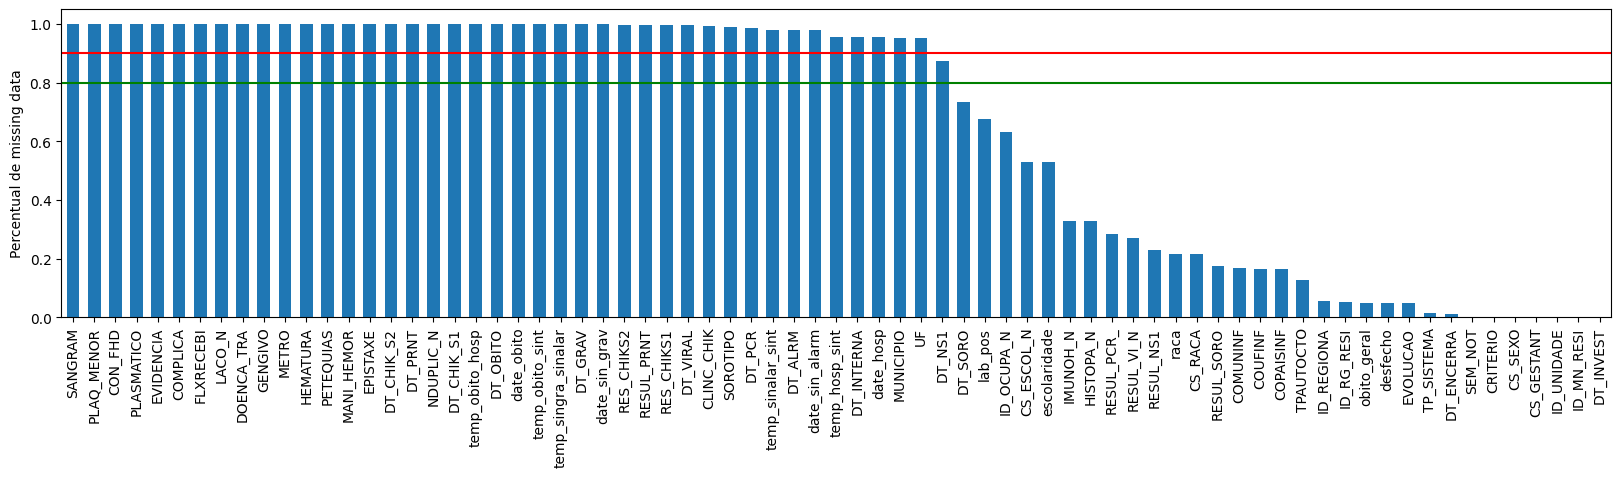

In [39]:
base[vars_with_na].isnull().mean().sort_values(ascending = False).plot.bar(figsize=(20,4), width=0.6)
plt.ylabel('Percentual de missing data')
plt.axhline(y=0.9,color='r', linestyle='-')
plt.axhline(y=0.8,color='g', linestyle='-')
plt.show()

## Dados de perfil

In [40]:
utils.plot_bar_por_variavel(df, variavel=sexo)


In [41]:
utils.plot_bar_por_variavel(df, variavel=gestante)


In [42]:
utils.plot_bar_por_variavel(df, variavel=raca)


In [43]:
utils.plot_bar_por_variavel(df, variavel=escolaridade)


In [44]:
utils.plot_bar_por_variavel(df, variavel=age_group)


C:\Users\danie\AppData\Local\Temp\ipykernel_10488\1080819665.py:5: FutureWarning:



The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.



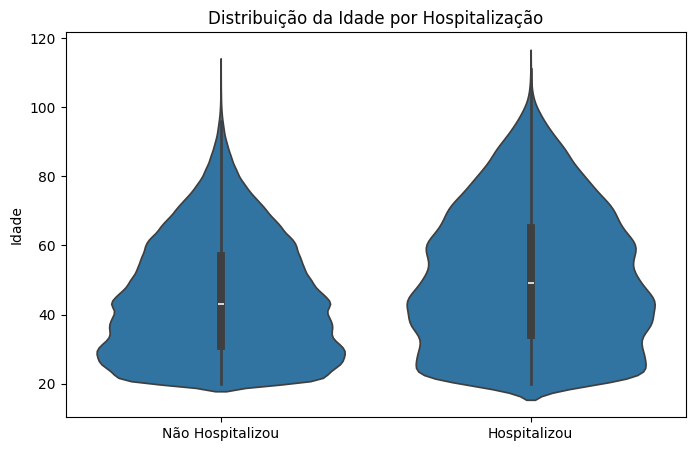

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.violinplot(
    data=df,
    x="HOSPITALIZ",  
    y="idade",       
    inner="box",     
    scale="width"     
)

plt.xticks([0,1], ["Não Hospitalizou", "Hospitalizou"])
plt.ylabel("Idade")
plt.xlabel("")
plt.title("Distribuição da Idade por Hospitalização")
plt.show()


## Sintomas

In [46]:
variavel_prin = 'sintomas'

In [47]:
lista = result[result.columns.tolist()[23:37]].columns.tolist()

label = preprocessing.LabelEncoder()
data_encoded = pd.DataFrame() 

for i in lista :
  data_encoded[i]=label.fit_transform(df[i])

def cramers_V(var1,var2):
  crosstab =np.array(pd.crosstab(var1,var2, rownames=None, colnames=None))
  stat = chi2_contingency(crosstab)[0] 
  obs = np.sum(crosstab)
  mini = min(crosstab.shape)-1
  return np.sqrt(stat/(obs*mini))

In [48]:
df[lista] = df[lista].fillna(0)


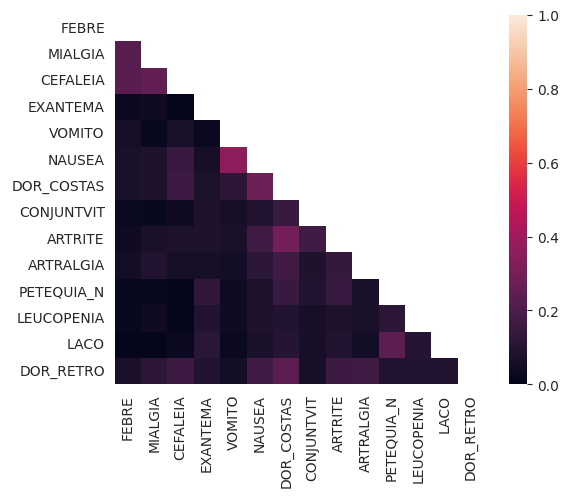

In [49]:
rows= []

for var1 in data_encoded:
  col = []
  for var2 in data_encoded :
    cramers =cramers_V(data_encoded[var1], data_encoded[var2]) 
    col.append(round(cramers,2)) 
  rows.append(col)
  
cramers_results = np.array(rows)
base_cor = pd.DataFrame(cramers_results, columns = data_encoded.columns, index =data_encoded.columns)

mask = np.zeros_like(base_cor, dtype=np.bool)
mask[np.triu_indices_from(mask)] = True

with sns.axes_style("white"):
  ax = sns.heatmap(base_cor, mask=mask,vmin=0., vmax=1, square=True)

plt.show()

In [50]:
pd.DataFrame(df[lista].sum())

,0
FEBRE,716372.0
MIALGIA,704189.0
CEFALEIA,699081.0
EXANTEMA,212068.0
VOMITO,186833.0
NAUSEA,341375.0
DOR_COSTAS,309768.0
CONJUNTVIT,32087.0
ARTRITE,118180.0
ARTRALGIA,197442.0


In [51]:
df = (
    df
    .assign(**{variavel_prin: lambda _df: _df[lista].sum(axis=1)})
    .sort_values(by=variavel_prin)
)


utils.plot_bar_por_variavel(df, variavel=variavel_prin, hospitaliz = 'HOSPITALIZ', replace=False, title = f'Quantidade de {variavel_prin} por hospitalização')

In [52]:
utils.plot_bar_por_variavel_inverso(df, lista, hospitaliz = 'HOSPITALIZ')

In [53]:
# lista = result[result.columns.tolist()[23:37]].columns.tolist()

for elemento in lista:
    utils.plot_bar_por_variavel(df, variavel=elemento)


## Comorbidades

In [54]:
variavel_prin = 'comorbidades'

In [55]:
lista = result[result.columns.tolist()[37:44]].columns.tolist()

label = preprocessing.LabelEncoder()
data_encoded = pd.DataFrame() 

for i in lista :
  data_encoded[i]=label.fit_transform(df[i])

def cramers_V(var1,var2):
  crosstab =np.array(pd.crosstab(var1,var2, rownames=None, colnames=None))
  stat = chi2_contingency(crosstab)[0] 
  obs = np.sum(crosstab)
  mini = min(crosstab.shape)-1
  return np.sqrt(stat/(obs*mini))

In [56]:
df[lista] = df[lista].fillna(0)

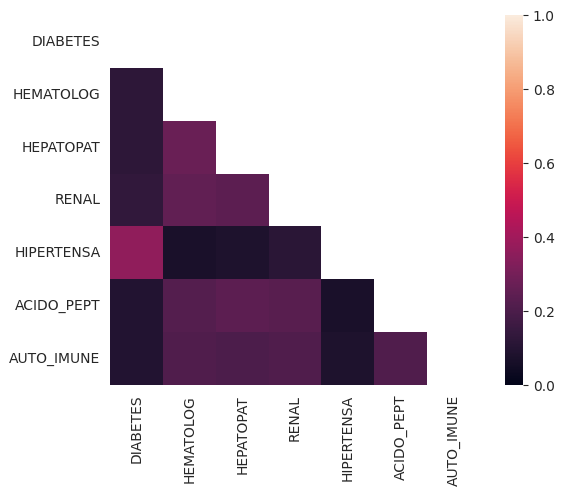

In [57]:
rows= []

for var1 in data_encoded:
  col = []
  for var2 in data_encoded :
    cramers =cramers_V(data_encoded[var1], data_encoded[var2]) 
    col.append(round(cramers,2)) 
  rows.append(col)
  
cramers_results = np.array(rows)
base_cor = pd.DataFrame(cramers_results, columns = data_encoded.columns, index =data_encoded.columns)

mask = np.zeros_like(base_cor, dtype=np.bool)
mask[np.triu_indices_from(mask)] = True

with sns.axes_style("white"):
  ax = sns.heatmap(base_cor, mask=mask,vmin=0., vmax=1, square=True)

plt.show()

In [58]:
pd.DataFrame(df[lista].sum())

,0
DIABETES,30422.0
HEMATOLOG,4367.0
HEPATOPAT,4646.0
RENAL,4072.0
HIPERTENSA,76290.0
ACIDO_PEPT,4790.0
AUTO_IMUNE,4498.0


In [59]:
df = (
    df
    .assign(**{variavel_prin: lambda _df: _df[lista].sum(axis=1)})
    .sort_values(by=variavel_prin)
)


utils.plot_bar_por_variavel(df, variavel=variavel_prin, replace=False, title = f'Quantidade de {variavel_prin} por hospitalização')

In [60]:
utils.plot_bar_por_variavel_inverso(df, lista, hospitaliz = 'HOSPITALIZ')

In [61]:
# lista = result[result.columns.tolist()[23:37]].columns.tolist()

for elemento in lista:
    utils.plot_bar_por_variavel(df, variavel=elemento)


## de alarme

In [62]:
variavel_prin = 'de_alarme'

In [63]:
lista = result[result.columns.tolist()[76:85]].columns.tolist()

label = preprocessing.LabelEncoder()
data_encoded = pd.DataFrame() 

for i in lista :
  data_encoded[i]=label.fit_transform(df[i])

def cramers_V(var1,var2):
  crosstab =np.array(pd.crosstab(var1,var2, rownames=None, colnames=None))
  stat = chi2_contingency(crosstab)[0] 
  obs = np.sum(crosstab)
  mini = min(crosstab.shape)-1
  return np.sqrt(stat/(obs*mini))

In [64]:
cond = (df['DT_ALRM'].notnull()) & (df['DT_INTERNA'].notnull()) & (df['DT_ALRM'] > df['DT_INTERNA'])

print(df.loc[cond, lista].shape[0]/df[(df['DT_ALRM'].notnull()) & (df['DT_INTERNA'].notnull())].shape[0])


0.14675446848541862


In [65]:
df = df.assign(
    diff_alarme = np.where(
        cond,
        (df['DT_ALRM'] - df['DT_INTERNA']),
        np.nan
    )
)

df['diff_alarme'].value_counts()

diff_alarme
1 day, 0:00:00          574
2 days, 0:00:00         241
3 days, 0:00:00         140
4 days, 0:00:00          71
5 days, 0:00:00          44
                       ... 
90 days, 0:00:00          1
140 days, 0:00:00         1
365242 days, 0:00:00      1
44 days, 0:00:00          1
51 days, 0:00:00          1
Name: count, Length: 103, dtype: int64

In [66]:
df['diff_alarme'] = pd.to_timedelta(df['diff_alarme'], errors='coerce')
df['diff_alarme'].median()

Timedelta('2 days 00:00:00')

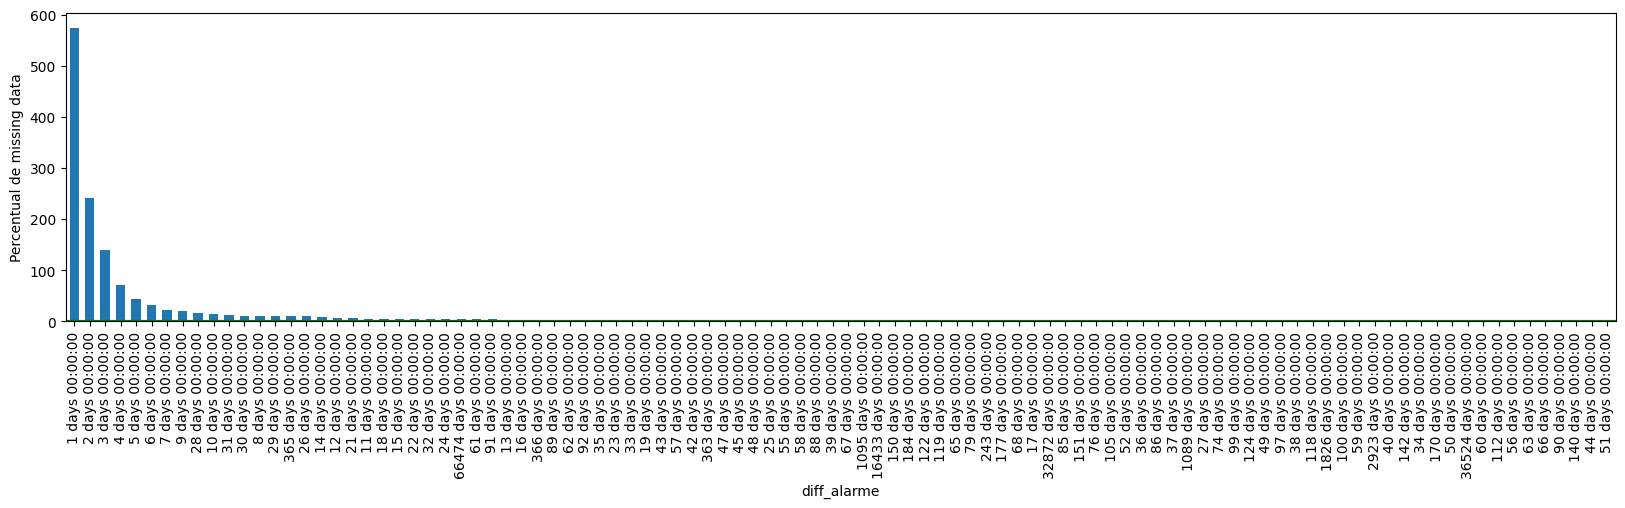

In [67]:
df['diff_alarme'].value_counts().plot.bar(figsize=(20,4), width=0.6)
plt.ylabel('Percentual de missing data')
plt.axhline(y=0.9,color='r', linestyle='-')
plt.axhline(y=0.8,color='g', linestyle='-')
plt.show()

In [68]:
df.loc[cond, lista] = df.loc[cond, lista].fillna(0)

In [69]:
df[lista] = df[lista].fillna(0)

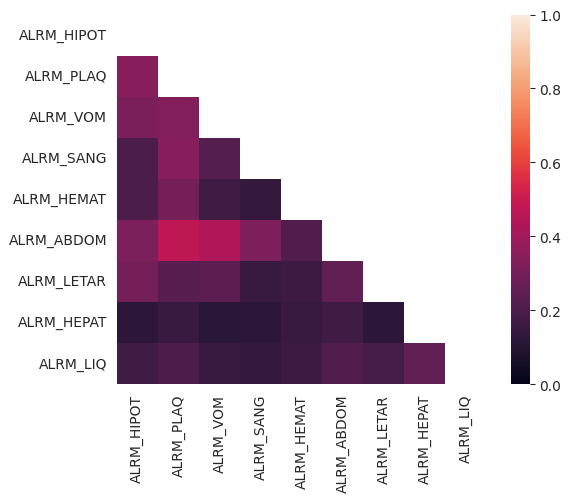

In [70]:
rows= []

for var1 in data_encoded:
  col = []
  for var2 in data_encoded :
    cramers =cramers_V(data_encoded[var1], data_encoded[var2]) 
    col.append(round(cramers,2)) 
  rows.append(col)
  
cramers_results = np.array(rows)
base_cor = pd.DataFrame(cramers_results, columns = data_encoded.columns, index =data_encoded.columns)

mask = np.zeros_like(base_cor, dtype=np.bool)
mask[np.triu_indices_from(mask)] = True

with sns.axes_style("white"):
  ax = sns.heatmap(base_cor, mask=mask,vmin=0., vmax=1, square=True)

plt.show()

In [71]:
pd.DataFrame(df[lista].sum())

,0
ALRM_HIPOT,2754.0
ALRM_PLAQ,11017.0
ALRM_VOM,2828.0
ALRM_SANG,3938.0
ALRM_HEMAT,1426.0
ALRM_ABDOM,6732.0
ALRM_LETAR,1441.0
ALRM_HEPAT,419.0
ALRM_LIQ,723.0


In [72]:
df = (
    df
    .assign(**{variavel_prin: lambda _df: _df[lista].sum(axis=1)})
    .sort_values(by=variavel_prin)
)


utils.plot_bar_por_variavel(df, variavel=variavel_prin, replace=False, title = f'Quantidade de {variavel_prin} por hospitalização')

In [73]:
utils.plot_bar_por_variavel_inverso(df, lista, hospitaliz = 'HOSPITALIZ')

In [74]:
# lista = result[result.columns.tolist()[23:37]].columns.tolist()

for elemento in lista:
    utils.plot_bar_por_variavel(df, variavel=elemento)


## Graves

In [75]:
variavel_prin = 'grave'

In [76]:
lista = result[result.columns.tolist()[86:101]].columns.tolist()

label = preprocessing.LabelEncoder()
data_encoded = pd.DataFrame() 

for i in lista :
  data_encoded[i]=label.fit_transform(df[i])

def cramers_V(var1,var2):
  crosstab =np.array(pd.crosstab(var1,var2, rownames=None, colnames=None))
  stat = chi2_contingency(crosstab)[0] 
  obs = np.sum(crosstab)
  mini = min(crosstab.shape)-1
  return np.sqrt(stat/(obs*mini))

In [77]:
cond = (df['DT_GRAV'].notnull()) & (df['DT_INTERNA'].notnull()) & (df['DT_GRAV'] > df['DT_INTERNA'])

print(df.loc[cond, lista].shape[0]/df[(df['DT_GRAV'].notnull()) & (df['DT_INTERNA'].notnull())].shape[0])
print(df.loc[cond, lista].shape[0])

df.loc[cond, lista] = df.loc[cond, lista].fillna(0)


0.3470533208606174
371


In [78]:
df = df.assign(diff_grave = np.where(cond, df['DT_GRAV'] - df['DT_INTERNA'], np.nan))
df['diff_grave'].value_counts()

diff_grave
1 days        135
2 days         55
3 days         54
5 days         22
4 days         18
6 days         11
7 days         10
9 days          9
8 days          8
12 days         4
26 days         4
10 days         4
14 days         3
11 days         3
30 days         3
17 days         2
13 days         2
31 days         2
16 days         2
19 days         2
18 days         1
37 days         1
25 days         1
15 days         1
58 days         1
42 days         1
91 days         1
116 days        1
1826 days       1
366 days        1
33 days         1
32 days         1
64 days         1
70 days         1
365 days        1
1095 days       1
29956 days      1
20 days         1
Name: count, dtype: int64

In [79]:
df['diff_grave'].median()

Timedelta('2 days 00:00:00')

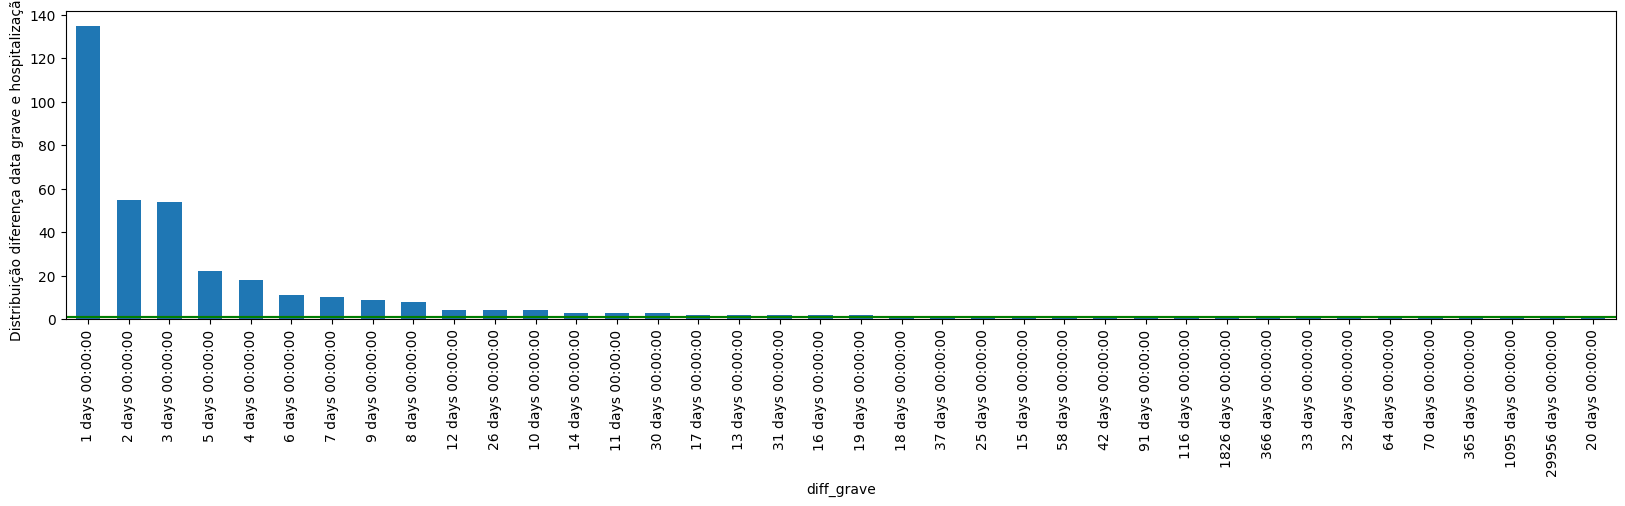

In [80]:
df['diff_grave'].value_counts().plot.bar(figsize=(20,4), width=0.6)
plt.ylabel('Distribuição diferença data grave e hospitalização')
plt.axhline(y=0.9,color='r', linestyle='-')
plt.axhline(y=0.8,color='g', linestyle='-')
plt.show()

In [81]:
df.loc[cond, lista] = df.loc[cond, lista].fillna(0)

In [82]:
df[lista] = df[lista].fillna(0)

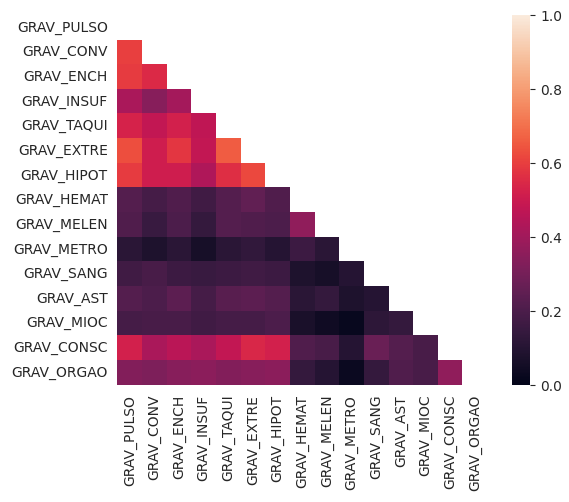

In [83]:
rows= []

for var1 in data_encoded:
  col = []
  for var2 in data_encoded :
    cramers =cramers_V(data_encoded[var1], data_encoded[var2]) 
    col.append(round(cramers,2)) 
  rows.append(col)
  
cramers_results = np.array(rows)
base_cor = pd.DataFrame(cramers_results, columns = data_encoded.columns, index =data_encoded.columns)

mask = np.zeros_like(base_cor, dtype=np.bool)
mask[np.triu_indices_from(mask)] = True

with sns.axes_style("white"):
  ax = sns.heatmap(base_cor, mask=mask,vmin=0., vmax=1, square=True)

plt.show()

In [84]:
pd.DataFrame(df[lista].sum())

,0
GRAV_PULSO,319.0
GRAV_CONV,194.0
GRAV_ENCH,235.0
GRAV_INSUF,365.0
GRAV_TAQUI,468.0
GRAV_EXTRE,479.0
GRAV_HIPOT,415.0
GRAV_HEMAT,267.0
GRAV_MELEN,227.0
GRAV_METRO,89.0


In [85]:
df = (
    df
    .assign(**{variavel_prin: lambda _df: _df[lista].sum(axis=1)})
    .sort_values(by=variavel_prin)
)


utils.plot_bar_por_variavel(df, variavel=variavel_prin, replace=False, title = f'Quantidade de {variavel_prin} por hospitalização')

In [86]:
utils.plot_bar_por_variavel_inverso(df, lista, hospitaliz = 'HOSPITALIZ')

In [87]:
# lista = result[result.columns.tolist()[23:37]].columns.tolist()

for elemento in lista:
    utils.plot_bar_por_variavel(df, variavel=elemento)


In [88]:
df.to_parquet('fontes/df_tratado.parquet')